# Phase I: Isolated scenario

**Building:** H Building · **Model:** `models/h_isolated.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/h_isolated_orientation_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with a single decision variable (building orientation, EnergyPlus `North Axis`, 0–359°). Run this notebook from its own folder (paths are relative to `notebooks/`).

## Running the evaluations for the optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation model

In [2]:
building = ef.get_building('../models/h_isolated.idf') # Loading the E+ model;

### Variables of the multi-objective analysis

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="BUILDING",             # Class of E+;
                    object_name="ElisRegina",    # Object name;
                    field_name="North Axis", # Object field;
                ),
                name='Orientation',
                value_descriptor=RangeParameter(min_val=0, max_val=359)      # Range
                )
            )

### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=200, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

10:05:13.640054


### Results

In [6]:
results

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,353.082053,2.129020e+11,9.465062e+10,0,True
1,180.619924,2.083150e+11,9.755506e+10,0,True
2,178.795449,2.111543e+11,9.494836e+10,0,True
3,2.463354,2.089574e+11,9.711568e+10,0,True
4,184.984299,2.085118e+11,9.751278e+10,0,True
...,...,...,...,...,...
95,233.863347,2.310809e+11,9.656092e+10,0,False
96,202.808422,2.154873e+11,9.807831e+10,0,False
97,154.204656,2.204742e+11,9.657134e+10,0,False
98,60.472223,2.331166e+11,9.658144e+10,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/876.15)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/876.15)

results

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,353.082053,67.499232,30.008377,0,True
1,180.619924,66.044937,30.929209,0,True
2,178.795449,66.945138,30.102773,0,True
3,2.463354,66.248603,30.789907,0,True
4,184.984299,66.107335,30.915806,0,True
...,...,...,...,...,...
95,233.863347,73.262728,30.614026,0,False
96,202.808422,68.318882,31.095102,0,False
97,154.204656,69.899948,30.617328,0,False
98,60.472223,73.908142,30.620529,0,False


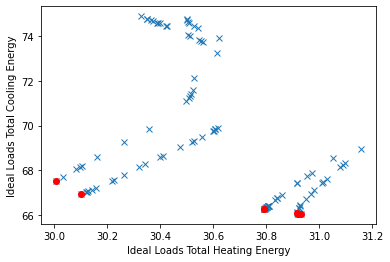

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/h_isolated_orientation_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

In [9]:
results

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,353.082053,67.499232,30.008377,0,True
1,180.619924,66.044937,30.929209,0,True
2,178.795449,66.945138,30.102773,0,True
3,2.463354,66.248603,30.789907,0,True
4,184.984299,66.107335,30.915806,0,True
...,...,...,...,...,...
95,233.863347,73.262728,30.614026,0,False
96,202.808422,68.318882,31.095102,0,False
97,154.204656,69.899948,30.617328,0,False
98,60.472223,73.908142,30.620529,0,False


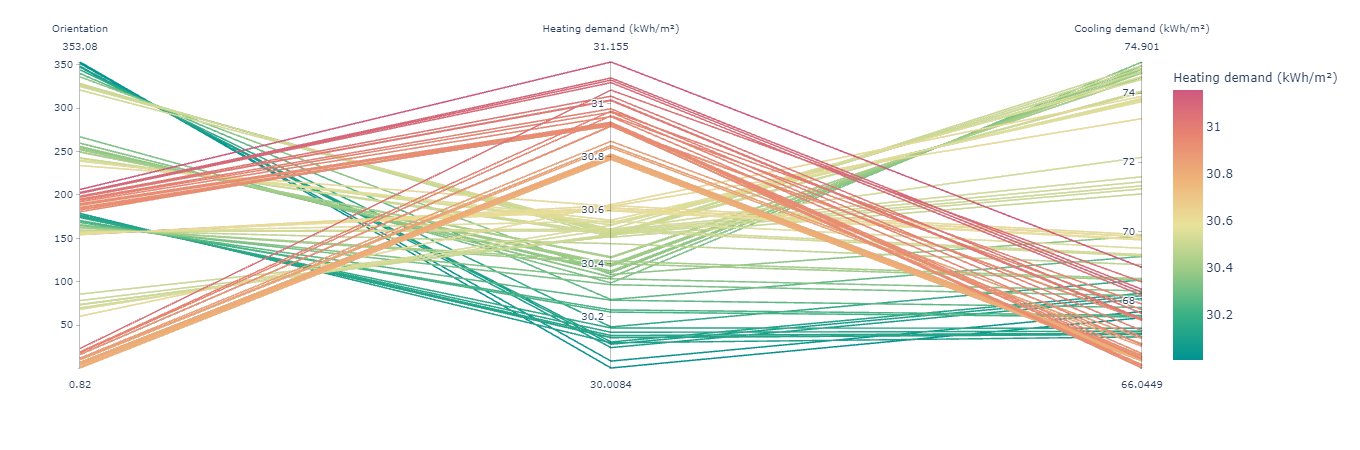

In [10]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["Orientation","Heating demand (kWh/m²)","Cooling demand (kWh/m²)"],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

##### optres

In [11]:
results.to_csv('../results/h_isolated_orientation_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
7,182.780112,66.052257,30.919247,0,True
